In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

print(df.head())
print(df.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [7]:
print(df.info())

print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

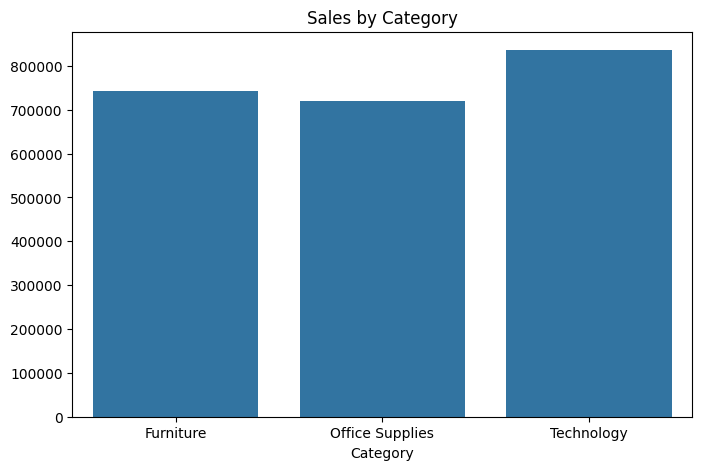

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=df.groupby('Category')['Sales'].sum().index,
    y=df.groupby('Category')['Sales'].sum().values
)
plt.title('Sales by Category')
plt.show()

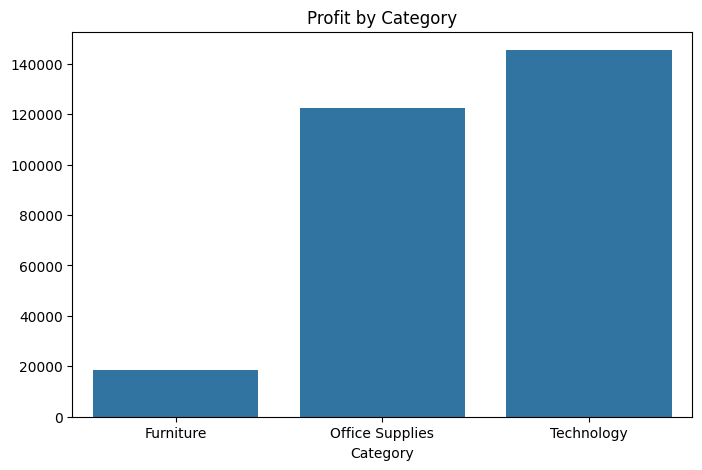

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=df.groupby('Category')['Profit'].sum().index,
    y=df.groupby('Category')['Profit'].sum().values
)
plt.title('Profit by Category')
plt.show()

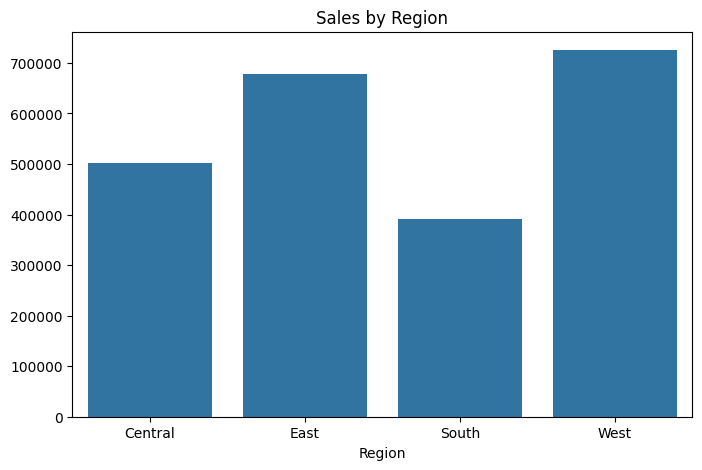

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=df.groupby('Region')['Sales'].sum().index,
    y=df.groupby('Region')['Sales'].sum().values
)
plt.title('Sales by Region')
plt.show()

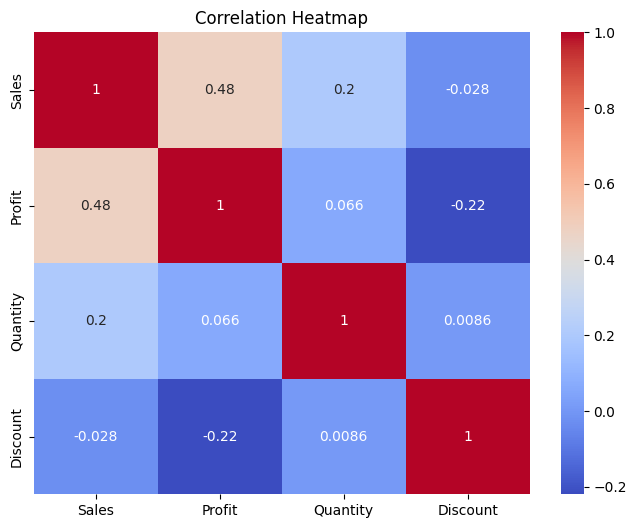

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Sales','Profit','Quantity','Discount']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
predictions = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 101.78767428483496
R2 Score: 0.5545712660322168


    Feature  Importance
2    Profit    0.918841
1  Discount    0.045995
0  Quantity    0.035163


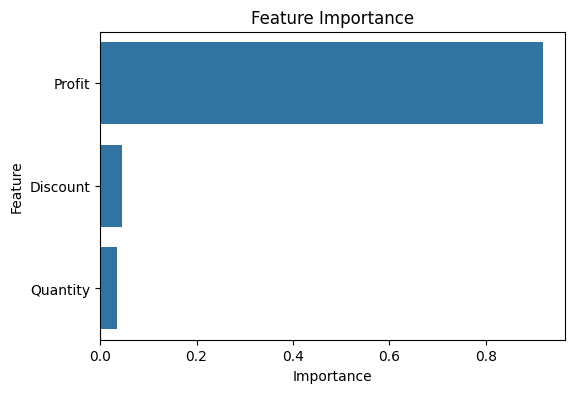

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(6,4))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance')
plt.show()